In [224]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [225]:
# %%
# Initialize dictionary to collect results for genetic models.
# Here we include the original "only_genetics" model.
all_results = defaultdict(list)
base_path = "/n/data2/hms/dbmi/kyu/lab/chb3333/gem-patho/models/actual_final_results"

# Loop over the "only_genetics" model for the given batches and experiments.
for gen_image in ['genetics_and_image', 'only_genetics', "only_image"]:
    for batch in ['all_batch']:
        for exp in ['cancertypebatching_exp_0_phase2_10', 
                    'cancertypebatching_exp_1_phase2_0']:
            path = f"{base_path}/{gen_image}/{batch}/{exp}/global_test_cindices.csv"
            try:
                data = pd.read_csv(path)
                for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
                    all_results['gen_image'].append(gen_image)
                    all_results['batch'].append(batch)
                    all_results['exp'].append(exp)
                    all_results['cancer'].append(cancer)
                    all_results['c_index'].append(c_idx)
            except Exception as e:
                # Skip missing or problematic files.
                print(f"Skipping file {path} due to error: {e}")


In [226]:
base_path2 = "/n/data2/hms/dbmi/kyu/lab/chb3333/gem-patho/models/improved_fusing"
for gen_image in ['layer_norm_fusion_mlp']:
    for exp in ['cancertypebatching_exp_0_phase2_10', 'cancertypebatching_exp_1_phase2_0']:
        # Note: Removed the extra slash in the path if not needed.
        path = f"{base_path2}/{gen_image}/{exp}/global_test_cindices.csv"
        try:
            data = pd.read_csv(path)
            for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
                all_results['gen_image'].append(gen_image)
                # Here we are using the model name as the batch.
                all_results['batch'].append("layer_norm_fusion_mlp")
                all_results['exp'].append(exp)
                all_results['cancer'].append(cancer)
                all_results['c_index'].append(c_idx)
        except Exception as e:
            # Skip missing or problematic files.
            print(f"Skipping file {path} due to error: {e}")


In [227]:
# %%
# Create a DataFrame from the collected results.
df = pd.DataFrame(all_results)
print("Raw Data:")
print(df.head())

# Group by model identifiers and calculate the average c-index and its standard error.
grouped = df.groupby(['gen_image', 'batch', 'exp'])['c_index'].agg(['mean', 'sem']).reset_index()
grouped.rename(columns={'mean': 'avg_c_index', 'sem': 'se_c_index'}, inplace=True)

# Create a column that uniquely identifies each model.
grouped["model"] = grouped["gen_image"] + "_" + grouped["batch"] + "_" + grouped["exp"]

# Compute the 95% confidence interval (CI = 1.96 * standard error).
grouped["ci95"] = 1.96 * grouped["se_c_index"]

print("Grouped Data:")
print(grouped)


Raw Data:
            gen_image      batch                                 exp  cancer  \
0  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10       8   
1  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10       2   
2  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10      10   
3  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10      12   
4  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10      11   

    c_index  
0  0.524150  
1  0.523948  
2  0.484390  
3  0.650224  
4  0.566925  
Grouped Data:
               gen_image                  batch  \
0     genetics_and_image              all_batch   
1     genetics_and_image              all_batch   
2  layer_norm_fusion_mlp  layer_norm_fusion_mlp   
3  layer_norm_fusion_mlp  layer_norm_fusion_mlp   
4          only_genetics              all_batch   
5          only_genetics              all_batch   
6             only_image              all_batch   
7  

In [228]:
grouped

,gen_image,batch,exp,avg_c_index,se_c_index,model,ci95
0,genetics_and_image,all_batch,cancertypebatching_exp_0_phase2_10,0.568642,0.009664,genetics_and_image_all_batch_cancertypebatchin...,0.018942
1,genetics_and_image,all_batch,cancertypebatching_exp_1_phase2_0,0.568063,0.010833,genetics_and_image_all_batch_cancertypebatchin...,0.021233
2,layer_norm_fusion_mlp,layer_norm_fusion_mlp,cancertypebatching_exp_0_phase2_10,0.598689,0.013779,layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...,0.027007
3,layer_norm_fusion_mlp,layer_norm_fusion_mlp,cancertypebatching_exp_1_phase2_0,0.589226,0.011080,layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...,0.021716
4,only_genetics,all_batch,cancertypebatching_exp_0_phase2_10,0.520306,0.012892,only_genetics_all_batch_cancertypebatching_exp...,0.025268
5,only_genetics,all_batch,cancertypebatching_exp_1_phase2_0,0.529688,0.017125,only_genetics_all_batch_cancertypebatching_exp...,0.033565
6,only_image,all_batch,cancertypebatching_exp_0_phase2_10,0.567504,0.009536,only_image_all_batch_cancertypebatching_exp_0_...,0.018691
7,only_image,all_batch,cancertypebatching_exp_1_phase2_0,0.570331,0.009507,only_image_all_batch_cancertypebatching_exp_1_...,0.018634


In [229]:
grouped.iloc[[0, 4]] = grouped.iloc[[4, 0]].values
grouped.iloc[[1, 5]] = grouped.iloc[[5, 1]].values

grouped.iloc[[2, 6]] = grouped.iloc[[6, 2]].values
grouped.iloc[[3, 7]] = grouped.iloc[[7, 3]].values




In [230]:
grouped

,gen_image,batch,exp,avg_c_index,se_c_index,model,ci95
0,only_genetics,all_batch,cancertypebatching_exp_0_phase2_10,0.520306,0.012892,only_genetics_all_batch_cancertypebatching_exp...,0.025268
1,only_genetics,all_batch,cancertypebatching_exp_1_phase2_0,0.529688,0.017125,only_genetics_all_batch_cancertypebatching_exp...,0.033565
2,only_image,all_batch,cancertypebatching_exp_0_phase2_10,0.567504,0.009536,only_image_all_batch_cancertypebatching_exp_0_...,0.018691
3,only_image,all_batch,cancertypebatching_exp_1_phase2_0,0.570331,0.009507,only_image_all_batch_cancertypebatching_exp_1_...,0.018634
4,genetics_and_image,all_batch,cancertypebatching_exp_0_phase2_10,0.568642,0.009664,genetics_and_image_all_batch_cancertypebatchin...,0.018942
5,genetics_and_image,all_batch,cancertypebatching_exp_1_phase2_0,0.568063,0.010833,genetics_and_image_all_batch_cancertypebatchin...,0.021233
6,layer_norm_fusion_mlp,layer_norm_fusion_mlp,cancertypebatching_exp_0_phase2_10,0.598689,0.013779,layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...,0.027007
7,layer_norm_fusion_mlp,layer_norm_fusion_mlp,cancertypebatching_exp_1_phase2_0,0.589226,0.011080,layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...,0.021716


In [231]:
# %%
# Assign sequential model numbers to each aggregated group.
grouped["model_number"] = range(1, len(grouped) + 1)
print("Model Numbers:")
print(grouped[['model_number', 'model']])


Model Numbers:
   model_number                                              model
0             1  only_genetics_all_batch_cancertypebatching_exp...
1             2  only_genetics_all_batch_cancertypebatching_exp...
2             3  only_image_all_batch_cancertypebatching_exp_0_...
3             4  only_image_all_batch_cancertypebatching_exp_1_...
4             5  genetics_and_image_all_batch_cancertypebatchin...
5             6  genetics_and_image_all_batch_cancertypebatchin...
6             7  layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...
7             8  layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...


In [232]:
# %%
# Define model label mapping.
# For the two only_genetics experiments we assign different names,
# and assign names for one_hot and ct_specific groups.
model_labels = {
    "PhasedCTBatchModel": "Phased CT-Batch Model",  # for exp "cancertypebatching_exp_0_phase2_10"
    "UniformBatchModel": "Uniform Batch Model"      # for exp "cancertypebatching_exp_1_phase2_0"
}

# Function to generate the label based on the "model" string.
def get_model_label(model_str):
    if "cancertypebatching_exp_0_phase2_10" in model_str:
         return model_labels["PhasedCTBatchModel"]
    elif "cancertypebatching_exp_1_phase2_0" in model_str:
         return model_labels["UniformBatchModel"]
    else:
         return model_str

# Apply the label mapping.
grouped["model_label"] = grouped["model"].apply(get_model_label)





In [233]:
grouped["model_label"]

0    Phased CT-Batch Model
1      Uniform Batch Model
2    Phased CT-Batch Model
3      Uniform Batch Model
4    Phased CT-Batch Model
5      Uniform Batch Model
6    Phased CT-Batch Model
7      Uniform Batch Model
Name: model_label, dtype: object

In [234]:
# %%
# Assign sequential model numbers to each aggregated group.
grouped["model_number"] = range(1, len(grouped) + 1)
print("Model Numbers:")
print(grouped[['model_number', 'model']])


Model Numbers:
   model_number                                              model
0             1  only_genetics_all_batch_cancertypebatching_exp...
1             2  only_genetics_all_batch_cancertypebatching_exp...
2             3  only_image_all_batch_cancertypebatching_exp_0_...
3             4  only_image_all_batch_cancertypebatching_exp_1_...
4             5  genetics_and_image_all_batch_cancertypebatchin...
5             6  genetics_and_image_all_batch_cancertypebatchin...
6             7  layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...
7             8  layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...


In [235]:
# %%
# Define model label mapping.
# For the two only_genetics experiments we assign different names,
# and assign names for one_hot and ct_specific groups.
model_labels = {
    "PhasedCTBatchModel": "Phased CT-Batch Model",  # for exp "cancertypebatching_exp_0_phase2_10"
    "UniformBatchModel": "Uniform Batch Model"      # for exp "cancertypebatching_exp_1_phase2_0"
}

# Function to generate the label based on the "model" string.
def get_model_label(model_str):
    if "cancertypebatching_exp_0_phase2_10" in model_str:
         return model_labels["PhasedCTBatchModel"]
    elif "cancertypebatching_exp_1_phase2_0" in model_str:
         return model_labels["UniformBatchModel"]
    else:
         return model_str

# Apply the label mapping.
grouped["model_label"] = grouped["model"].apply(get_model_label)





In [236]:
grouped

,gen_image,batch,exp,avg_c_index,se_c_index,model,ci95,model_number,model_label
0,only_genetics,all_batch,cancertypebatching_exp_0_phase2_10,0.520306,0.012892,only_genetics_all_batch_cancertypebatching_exp...,0.025268,1,Phased CT-Batch Model
1,only_genetics,all_batch,cancertypebatching_exp_1_phase2_0,0.529688,0.017125,only_genetics_all_batch_cancertypebatching_exp...,0.033565,2,Uniform Batch Model
2,only_image,all_batch,cancertypebatching_exp_0_phase2_10,0.567504,0.009536,only_image_all_batch_cancertypebatching_exp_0_...,0.018691,3,Phased CT-Batch Model
3,only_image,all_batch,cancertypebatching_exp_1_phase2_0,0.570331,0.009507,only_image_all_batch_cancertypebatching_exp_1_...,0.018634,4,Uniform Batch Model
4,genetics_and_image,all_batch,cancertypebatching_exp_0_phase2_10,0.568642,0.009664,genetics_and_image_all_batch_cancertypebatchin...,0.018942,5,Phased CT-Batch Model
5,genetics_and_image,all_batch,cancertypebatching_exp_1_phase2_0,0.568063,0.010833,genetics_and_image_all_batch_cancertypebatchin...,0.021233,6,Uniform Batch Model
6,layer_norm_fusion_mlp,layer_norm_fusion_mlp,cancertypebatching_exp_0_phase2_10,0.598689,0.013779,layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...,0.027007,7,Phased CT-Batch Model
7,layer_norm_fusion_mlp,layer_norm_fusion_mlp,cancertypebatching_exp_1_phase2_0,0.589226,0.011080,layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...,0.021716,8,Uniform Batch Model


In [237]:
# %%
# Replace the color_map with:
color_map = {
    "only_genetics": "tab:green",
    "only_image": "tab:orange",  # Your new purple
    "genetics_and_image": "tab:blue",
    "improved_fusion": "tab:red"
}

# Function to determine the color based on the model's key.
def get_color(model_str):
    if model_str.startswith("only_genetics"):
        return color_map["only_genetics"]
    elif model_str.startswith("only_image"):
        return color_map["only_image"]
    elif model_str.startswith("genetics_and_image"):
        return color_map["genetics_and_image"]

    elif model_str.startswith("layer_norm_fusion"):
        return color_map["improved_fusion"]
    else:
        return "tab:gray"


# Map each model to its assigned color.
colors = grouped["model"].apply(get_color)


In [238]:
colors = grouped["model"].apply(get_color)


def get_model_class(row):
    model_str = row["model"]
    model_label = row["model_label"]
    
    if model_str.startswith("only_genetics"):
        return "Genetics: " + model_label
    elif model_str.startswith("only_image"):
        return "Image: " + model_label
    elif model_str.startswith("genetics_and_image"):
        return "Multimodal: " + model_label

    else:
        return "Improved Fusion: " + model_label


grouped["model_label_complete"] = grouped.apply(get_model_class, axis=1)



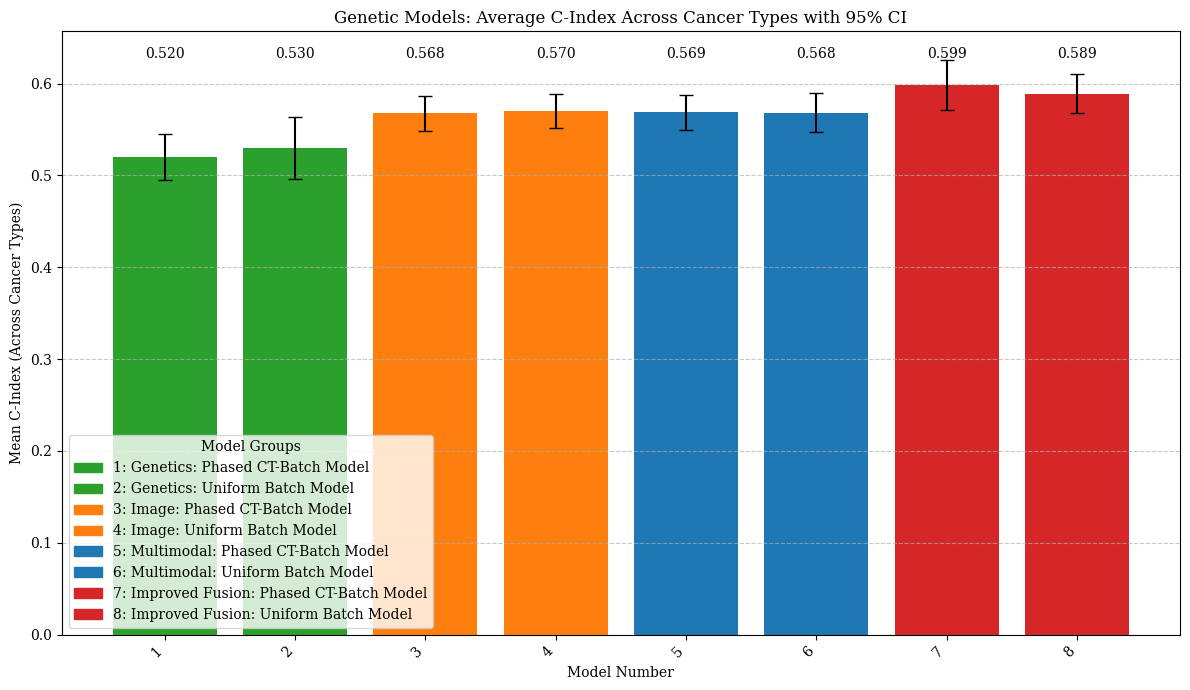

In [239]:
# %%
# Create the final bar plot.
plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(grouped)), grouped["avg_c_index"],
               yerr=grouped["ci95"], capsize=5, color=colors)

# Keep numbers at the bottom.
plt.xticks(range(len(grouped)), grouped["model_number"], rotation=45, ha='right')
plt.ylabel("Mean C-Index (Across Cancer Types)")
plt.xlabel("Model Number")
plt.title("Genetic Models: Average C-Index Across Cancer Types with 95% CI")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add numerical labels atop each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 0.625, f'{height:.3f}', ha='center', va='bottom', fontsize=10)


# Build a custom legend.
# Build a custom legend that includes model numbers and labels.
legend_patches = []
for _, row in grouped.iterrows():
    legend_label = f"{row['model_number']}: {row['model_label_complete']}"
    legend_patches.append(mpatches.Patch(color=get_color(row['model']), label=legend_label))
plt.legend(handles=legend_patches, title="Model Groups")

plt.show()


In [240]:
grouped

,gen_image,batch,exp,avg_c_index,se_c_index,model,ci95,model_number,model_label,model_label_complete
0,only_genetics,all_batch,cancertypebatching_exp_0_phase2_10,0.520306,0.012892,only_genetics_all_batch_cancertypebatching_exp...,0.025268,1,Phased CT-Batch Model,Genetics: Phased CT-Batch Model
1,only_genetics,all_batch,cancertypebatching_exp_1_phase2_0,0.529688,0.017125,only_genetics_all_batch_cancertypebatching_exp...,0.033565,2,Uniform Batch Model,Genetics: Uniform Batch Model
2,only_image,all_batch,cancertypebatching_exp_0_phase2_10,0.567504,0.009536,only_image_all_batch_cancertypebatching_exp_0_...,0.018691,3,Phased CT-Batch Model,Image: Phased CT-Batch Model
3,only_image,all_batch,cancertypebatching_exp_1_phase2_0,0.570331,0.009507,only_image_all_batch_cancertypebatching_exp_1_...,0.018634,4,Uniform Batch Model,Image: Uniform Batch Model
4,genetics_and_image,all_batch,cancertypebatching_exp_0_phase2_10,0.568642,0.009664,genetics_and_image_all_batch_cancertypebatchin...,0.018942,5,Phased CT-Batch Model,Multimodal: Phased CT-Batch Model
5,genetics_and_image,all_batch,cancertypebatching_exp_1_phase2_0,0.568063,0.010833,genetics_and_image_all_batch_cancertypebatchin...,0.021233,6,Uniform Batch Model,Multimodal: Uniform Batch Model
6,layer_norm_fusion_mlp,layer_norm_fusion_mlp,cancertypebatching_exp_0_phase2_10,0.598689,0.013779,layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...,0.027007,7,Phased CT-Batch Model,Improved Fusion: Phased CT-Batch Model
7,layer_norm_fusion_mlp,layer_norm_fusion_mlp,cancertypebatching_exp_1_phase2_0,0.589226,0.011080,layer_norm_fusion_mlp_layer_norm_fusion_mlp_ca...,0.021716,8,Uniform Batch Model,Improved Fusion: Uniform Batch Model


METRICS CALCULATION

In [241]:
cancer_mapping = {
    'ACC': 0, 'BLCA': 1, 'BRCA': 2, 'CESC': 3, 'CHOL': 4, 'CNTL': 5,
    'COAD': 6, 'DLBC': 7, 'ESCA': 8, 'FPPP': 9, 'GBM': 10, 'HNSC': 11,
    'KICH': 12, 'KIRC': 13, 'KIRP': 14, 'LAML': 15, 'LCML': 16, 'LGG': 17,
    'LIHC': 18, 'LUAD': 19, 'LUSC': 20, 'MESO': 21, 'MISC': 22, 'OV': 23,
    'PAAD': 24, 'PCPG': 25, 'PRAD': 26, 'READ': 27, 'SARC': 28, 'SKCM': 29,
    'STAD': 30, 'TGCT': 31, 'THCA': 32, 'THYM': 33, 'UCEC': 34, 'UCS': 35,
    'UVM': 36
}

inv_mapping = {v: k for k, v in cancer_mapping.items()}

In [242]:
import pandas as pd
import numpy as np

# Replace with your actual file path
file_path = '/home/chb3333/yulab/chb3333/gem-patho/models/improved_fusing/layer_norm_fusion_mlp/cancertypebatching_exp_0_phase2_10/global_test_cindices.csv'

# Load the CSV file
df = pd.read_csv(file_path)

# Calculate the average of the 'c_index' column
mean_c_index = df['c_index'].mean()
print("Average c_index:", mean_c_index)

# Make a copy to avoid SettingWithCopyWarning
filtered_df = df[df['c_index'] > 0.55].copy()

# Count how many rows have a c_index above 0.55
count_over = len(filtered_df)

# Calculate the average of the c_index values for those rows
average_over = filtered_df['c_index'].mean()

print("Count of c_index values over 0.55:", count_over)
print("Average c_index for values over 0.55:", average_over)

# Select the top 5 c_index values
top5 = df['c_index'].nlargest(5)

# Calculate mean and standard deviation
top5_avg = top5.mean()
top5_std = top5.std(ddof=1)  # sample std dev

# Compute standard error
top5_se = top5_std / np.sqrt(len(top5))

# Compute 95% confidence interval using normal approximation (1.96 * SE)
top5_ci95 = 1.96 * top5_se

print("Average of top 5 c_index values:", top5_avg)
print("Standard deviation of top 5 c_index values:", top5_std)
print("Standard error:", top5_se)
print(f"95% CI: [{top5_avg - top5_ci95:.4f}, {top5_avg + top5_ci95:.4f}]")

# Replace cancer_type using inverse mapping
filtered_df['cancer_type'] = filtered_df['cancer_type'].map(inv_mapping)

print("\nRows with c_index > 0.55:")
print(filtered_df)


Average c_index: 0.5986890387697241
Count of c_index values over 0.55: 22
Average c_index for values over 0.55: 0.6363075135619731
Average of top 5 c_index values: 0.7376786215202971
Standard deviation of top 5 c_index values: 0.04783945577451672
Standard error: 0.021394455023682847
95% CI: [0.6957, 0.7796]

Rows with c_index > 0.55:
   cancer_type   c_index
1         BRCA  0.604596
3         KICH  0.730942
4         HNSC  0.597086
5          LGG  0.656863
7         KIRC  0.678942
11        DLBC  0.812766
13        CHOL  0.565217
14        BLCA  0.575301
15         ACC  0.742304
16        MESO  0.576399
17        LIHC  0.592325
20        KIRP  0.677461
22        SARC  0.591798
23        READ  0.610396
25        THYM  0.681356
26        PCPG  0.721026
27        THCA  0.663433
28        STAD  0.557071
29        TGCT  0.621701
30        PAAD  0.562215
31        SKCM  0.580065
32        UCEC  0.599502


In [243]:
import pandas as pd
import numpy as np

# Replace with your actual file path
file_path = '/home/chb3333/yulab/chb3333/gem-patho/models/improved_fusing/layer_norm_fusion_mlp/cancertypebatching_exp_1_phase2_0/global_test_cindices.csv'

# Load the CSV file
df = pd.read_csv(file_path)

# Calculate the average of the 'c_index' column
mean_c_index = df['c_index'].mean()
print("Average c_index:", mean_c_index)

# Make a copy to avoid SettingWithCopyWarning
filtered_df = df[df['c_index'] > 0.55].copy()

# Count how many rows have a c_index above 0.55
count_over = len(filtered_df)

# Calculate the average of the c_index values for those rows
average_over = filtered_df['c_index'].mean()

print("Count of c_index values over 0.55:", count_over)
print("Average c_index for values over 0.55:", average_over)

# Select the top 5 c_index values
top5 = df['c_index'].nlargest(5)

# Calculate mean and standard deviation
top5_avg = top5.mean()
top5_std = top5.std(ddof=1)  # sample std dev

# Compute standard error
top5_se = top5_std / np.sqrt(len(top5))

# Compute 95% confidence interval using normal approximation (1.96 * SE)
top5_ci95 = 1.96 * top5_se

print("Average of top 5 c_index values:", top5_avg)
print("Standard deviation of top 5 c_index values:", top5_std)
print("Standard error:", top5_se)
print(f"95% CI: [{top5_avg - top5_ci95:.4f}, {top5_avg + top5_ci95:.4f}]")

# Replace cancer_type using inverse mapping
filtered_df['cancer_type'] = filtered_df['cancer_type'].map(inv_mapping)

print("\nRows with c_index > 0.55:")
print(filtered_df)


Average c_index: 0.5892261654537627
Count of c_index values over 0.55: 24
Average c_index for values over 0.55: 0.6136758573721295
Average of top 5 c_index values: 0.7061160607112441
Standard deviation of top 5 c_index values: 0.04411354667040895
Standard error: 0.01972817781672878
95% CI: [0.6674, 0.7448]

Rows with c_index > 0.55:
   cancer_type   c_index
0         ESCA  0.555440
1         BRCA  0.613315
3         KICH  0.585202
4         HNSC  0.581493
5          LGG  0.670085
7         KIRC  0.687624
8         LUSC  0.555975
10        COAD  0.555836
11        DLBC  0.770213
13        CHOL  0.598662
14        BLCA  0.598466
15         ACC  0.732870
16        MESO  0.569225
17        LIHC  0.571287
20        KIRP  0.642973
21        PRAD  0.592288
22        SARC  0.591218
23        READ  0.588266
25        THYM  0.623729
26        PCPG  0.605128
27        THCA  0.669789
28        STAD  0.580244
31        SKCM  0.571218
32        UCEC  0.617676


Analysis of Models

In [244]:
df

,cancer_type,c_index
0,8,0.555440
1,2,0.613315
2,10,0.525300
3,12,0.585202
4,11,0.581493
5,17,0.670085
6,15,0.492513
7,13,0.687624
8,20,0.555975
9,19,0.533734


In [245]:
# %%
# Create a DataFrame from all_results if not already done.
# (Skip this cell if you already have 'df' built from all_results.)
aggregated_df = pd.DataFrame(all_results)

# Create a new column to uniquely identify each model.
aggregated_df['model'] = aggregated_df['gen_image'] + "_" + aggregated_df['batch'] + "_" + aggregated_df['exp']

# Display a preview of the aggregated data.
print("Aggregated Data:")
print(aggregated_df.head())


Aggregated Data:
            gen_image      batch                                 exp  cancer  \
0  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10       8   
1  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10       2   
2  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10      10   
3  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10      12   
4  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10      11   

    c_index                                              model  
0  0.524150  genetics_and_image_all_batch_cancertypebatchin...  
1  0.523948  genetics_and_image_all_batch_cancertypebatchin...  
2  0.484390  genetics_and_image_all_batch_cancertypebatchin...  
3  0.650224  genetics_and_image_all_batch_cancertypebatchin...  
4  0.566925  genetics_and_image_all_batch_cancertypebatchin...  


In [246]:
# %%
# Create a pivot table where:
# - The index (rows) are the cancer types.
# - The columns are the unique models.
# - The values are the corresponding c-index values.
# This assumes that each model has one c-index per cancer type;
# if there are multiple values per cancer type-model pair, you can adjust the aggregation (e.g., using np.mean).
pivot_cindices = pd.pivot_table(aggregated_df,
                                index='cancer',
                                columns='model',
                                values='c_index',
                                aggfunc=np.mean)  # use mean in case of duplicates

# Print and display the pivot table.
print("Cancer Type Specific C-Indices Table:")
print(pivot_cindices)


Cancer Type Specific C-Indices Table:
model   genetics_and_image_all_batch_cancertypebatching_exp_0_phase2_10  \
cancer                                                                    
0                                                0.731877                 
1                                                0.578671                 
2                                                0.523948                 
3                                                0.511351                 
4                                                0.623746                 
6                                                0.561801                 
7                                                0.587234                 
8                                                0.524150                 
10                                               0.484390                 
11                                               0.566925                 
12                                               0.650224     

/tmp/ipykernel_1389/1738991012.py:8: FutureWarning: The provided callable <function mean at 0x7f11f8116a20> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_cindices = pd.pivot_table(aggregated_df,


In [247]:
# %%
# Define the output CSV file path.
output_csv = "/home/chb3333/yulab/chb3333/gem-patho/presentation_figures/improved_fusion/cancer_type_specific_cindices_table.csv"

# Export the pivot table to a CSV file.
pivot_cindices.to_csv(output_csv)

print(f"Pivot table successfully exported to {output_csv}")


Pivot table successfully exported to /home/chb3333/yulab/chb3333/gem-patho/presentation_figures/improved_fusion/cancer_type_specific_cindices_table.csv


In [248]:
# Map the index of the pivot table from integers to cancer type names
pivot_cindices.index = pivot_cindices.index.map(inv_mapping)

# Now print or display the updated pivot table
print("Cancer Type Specific C-Indices Table (Mapped):")
print(pivot_cindices)


Cancer Type Specific C-Indices Table (Mapped):
model   genetics_and_image_all_batch_cancertypebatching_exp_0_phase2_10  \
cancer                                                                    
ACC                                              0.731877                 
BLCA                                             0.578671                 
BRCA                                             0.523948                 
CESC                                             0.511351                 
CHOL                                             0.623746                 
COAD                                             0.561801                 
DLBC                                             0.587234                 
ESCA                                             0.524150                 
GBM                                              0.484390                 
HNSC                                             0.566925                 
KICH                                             0.65

In [249]:
models_to_drop = ["genetics_and_image_all_batch_cancertypebatching_exp_0_phase2_10", "genetics_and_image_all_batch_cancertypebatching_exp_1_phase2_0"]

# If the models are in the columns, drop them. This works even if you have multiple models to drop.
pivot_cindices = pivot_cindices.drop(columns=models_to_drop, errors='ignore')


In [ ]:
desired_column_order = [
    "only_genetics_all_batch_cancertypebatching_exp_0_phase2_10", 
    "only_genetics_all_batch_cancertypebatching_exp_1_phase2_0",
    "only_image_all_batch_cancertypebatching_exp_0_phase2_10", 
    "only_image_all_batch_cancertypebatching_exp_1_phase2_0",
    "layer_norm_fusion_mlp_layer_norm_fusion_mlp_cancertypebatching_exp_0_phase2_10",
    "layer_norm_fusion_mlp_layer_norm_fusion_mlp_cancertypebatching_exp_1_phase2_0"
]

# Reorder the columns of the pivot table using the desired order.
pivot_cindices = pivot_cindices.reindex(columns=desired_column_order)

In [250]:
pivot_cindices

model,layer_norm_fusion_mlp_layer_norm_fusion_mlp_cancertypebatching_exp_0_phase2_10,layer_norm_fusion_mlp_layer_norm_fusion_mlp_cancertypebatching_exp_1_phase2_0,only_genetics_all_batch_cancertypebatching_exp_0_phase2_10,only_genetics_all_batch_cancertypebatching_exp_1_phase2_0,only_image_all_batch_cancertypebatching_exp_0_phase2_10,only_image_all_batch_cancertypebatching_exp_1_phase2_0
cancer,,,,,,
ACC,0.742304,0.732870,0.638530,0.670308,0.680238,0.685700
BLCA,0.575301,0.598466,0.503879,0.551383,0.552979,0.550696
BRCA,0.604596,0.613315,0.553148,0.521543,0.619910,0.627408
CESC,0.537454,0.547355,0.508351,0.502350,0.548355,0.539554
CHOL,0.565217,0.598662,0.476589,0.570234,0.561873,0.600334
COAD,0.546188,0.555836,0.483282,0.450303,0.556538,0.551907
DLBC,0.812766,0.770213,0.714894,0.731915,0.638298,0.629787
ESCA,0.529083,0.555440,0.498182,0.472605,0.463516,0.512205
GBM,0.519909,0.525300,0.502162,0.482185,0.501758,0.508168


/tmp/ipykernel_1389/3109859652.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_df = formatted_df.applymap(highlight)


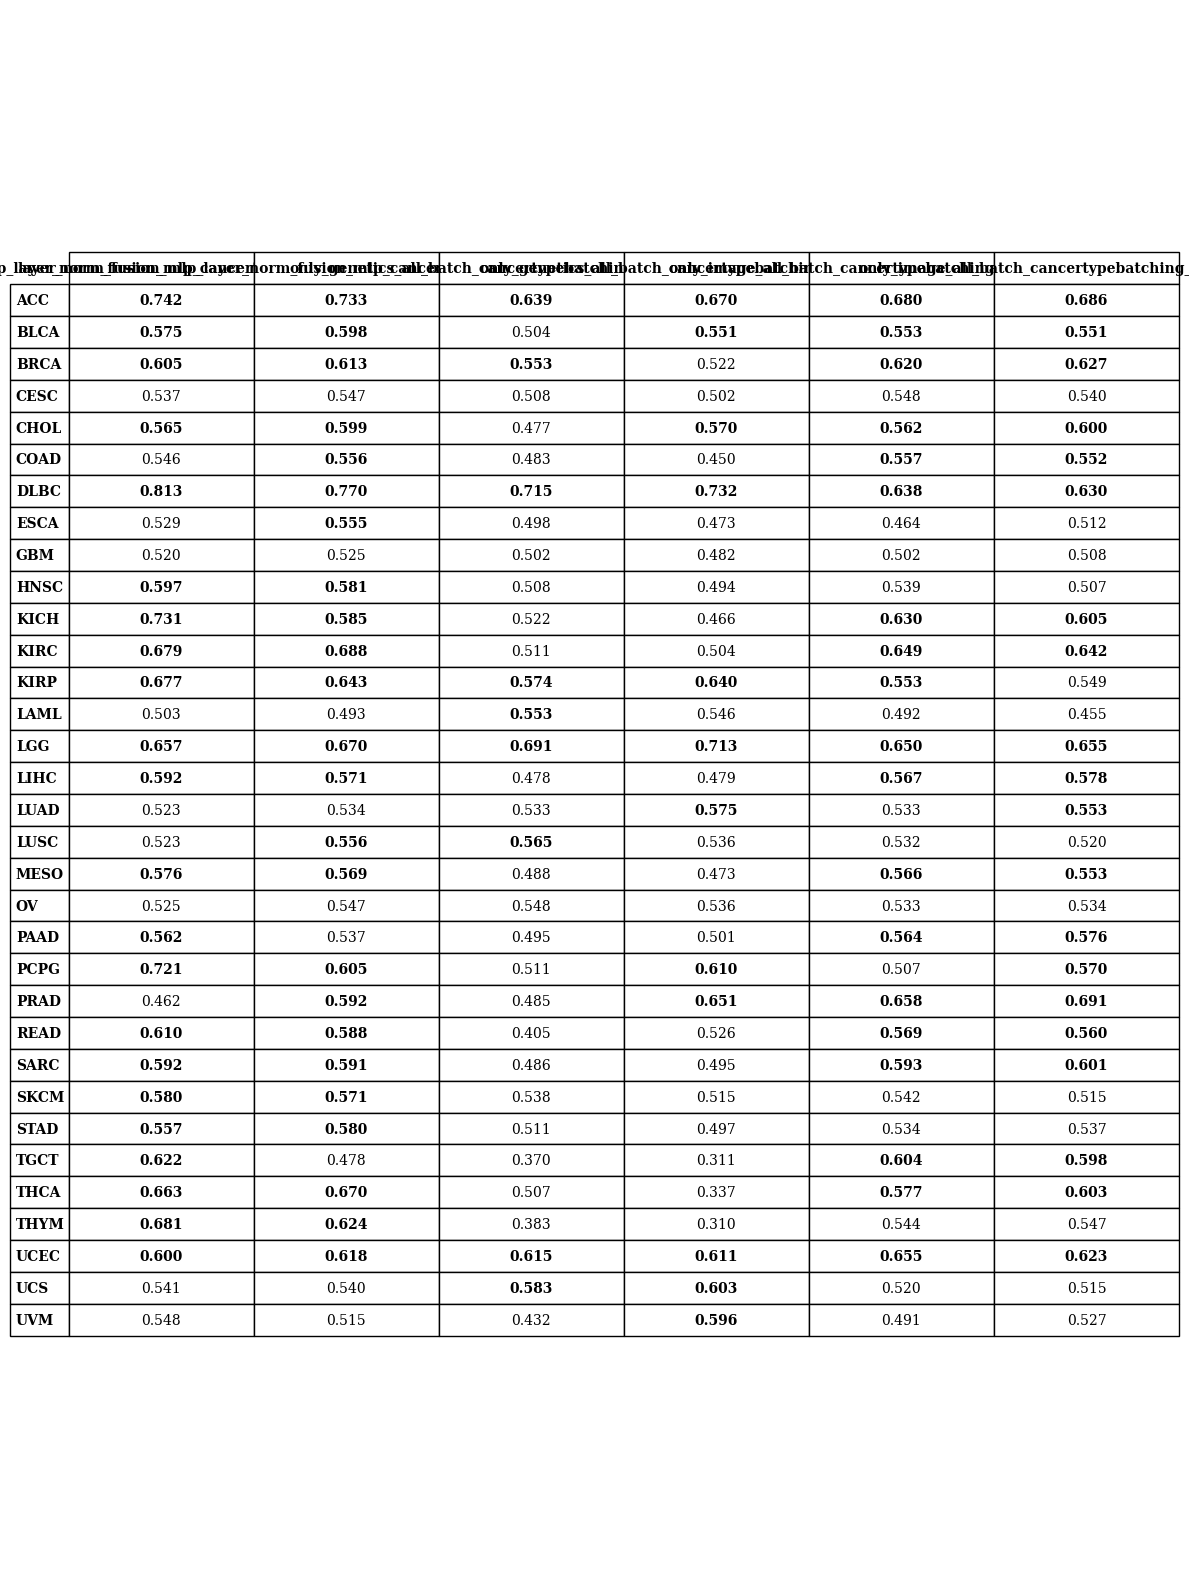

In [251]:
# Bold values above 0.55
def highlight(val):
    try:
        return f"**{val}**" if float(val) > 0.55 else val
    except:
        return val

formatted_df = formatted_df.applymap(highlight)

import matplotlib.pyplot as plt
import pandas.plotting as pd_plotting

fig, ax = plt.subplots(figsize=(12, 16))
ax.axis('off')
tbl = pd_plotting.table(ax, pivot_cindices.round(3), loc='center', cellLoc='center', colWidths=[0.2]*len(pivot_cindices.columns))

# Style cells
for (row, col), cell in tbl.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold')
    elif row > 0:
        val = pivot_cindices.iloc[row-1, col]
        if val > 0.55:
            cell.set_text_props(weight='bold')
        cell.get_text().set_text(f"{val:.3f}")

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

plt.tight_layout()
plt.show()

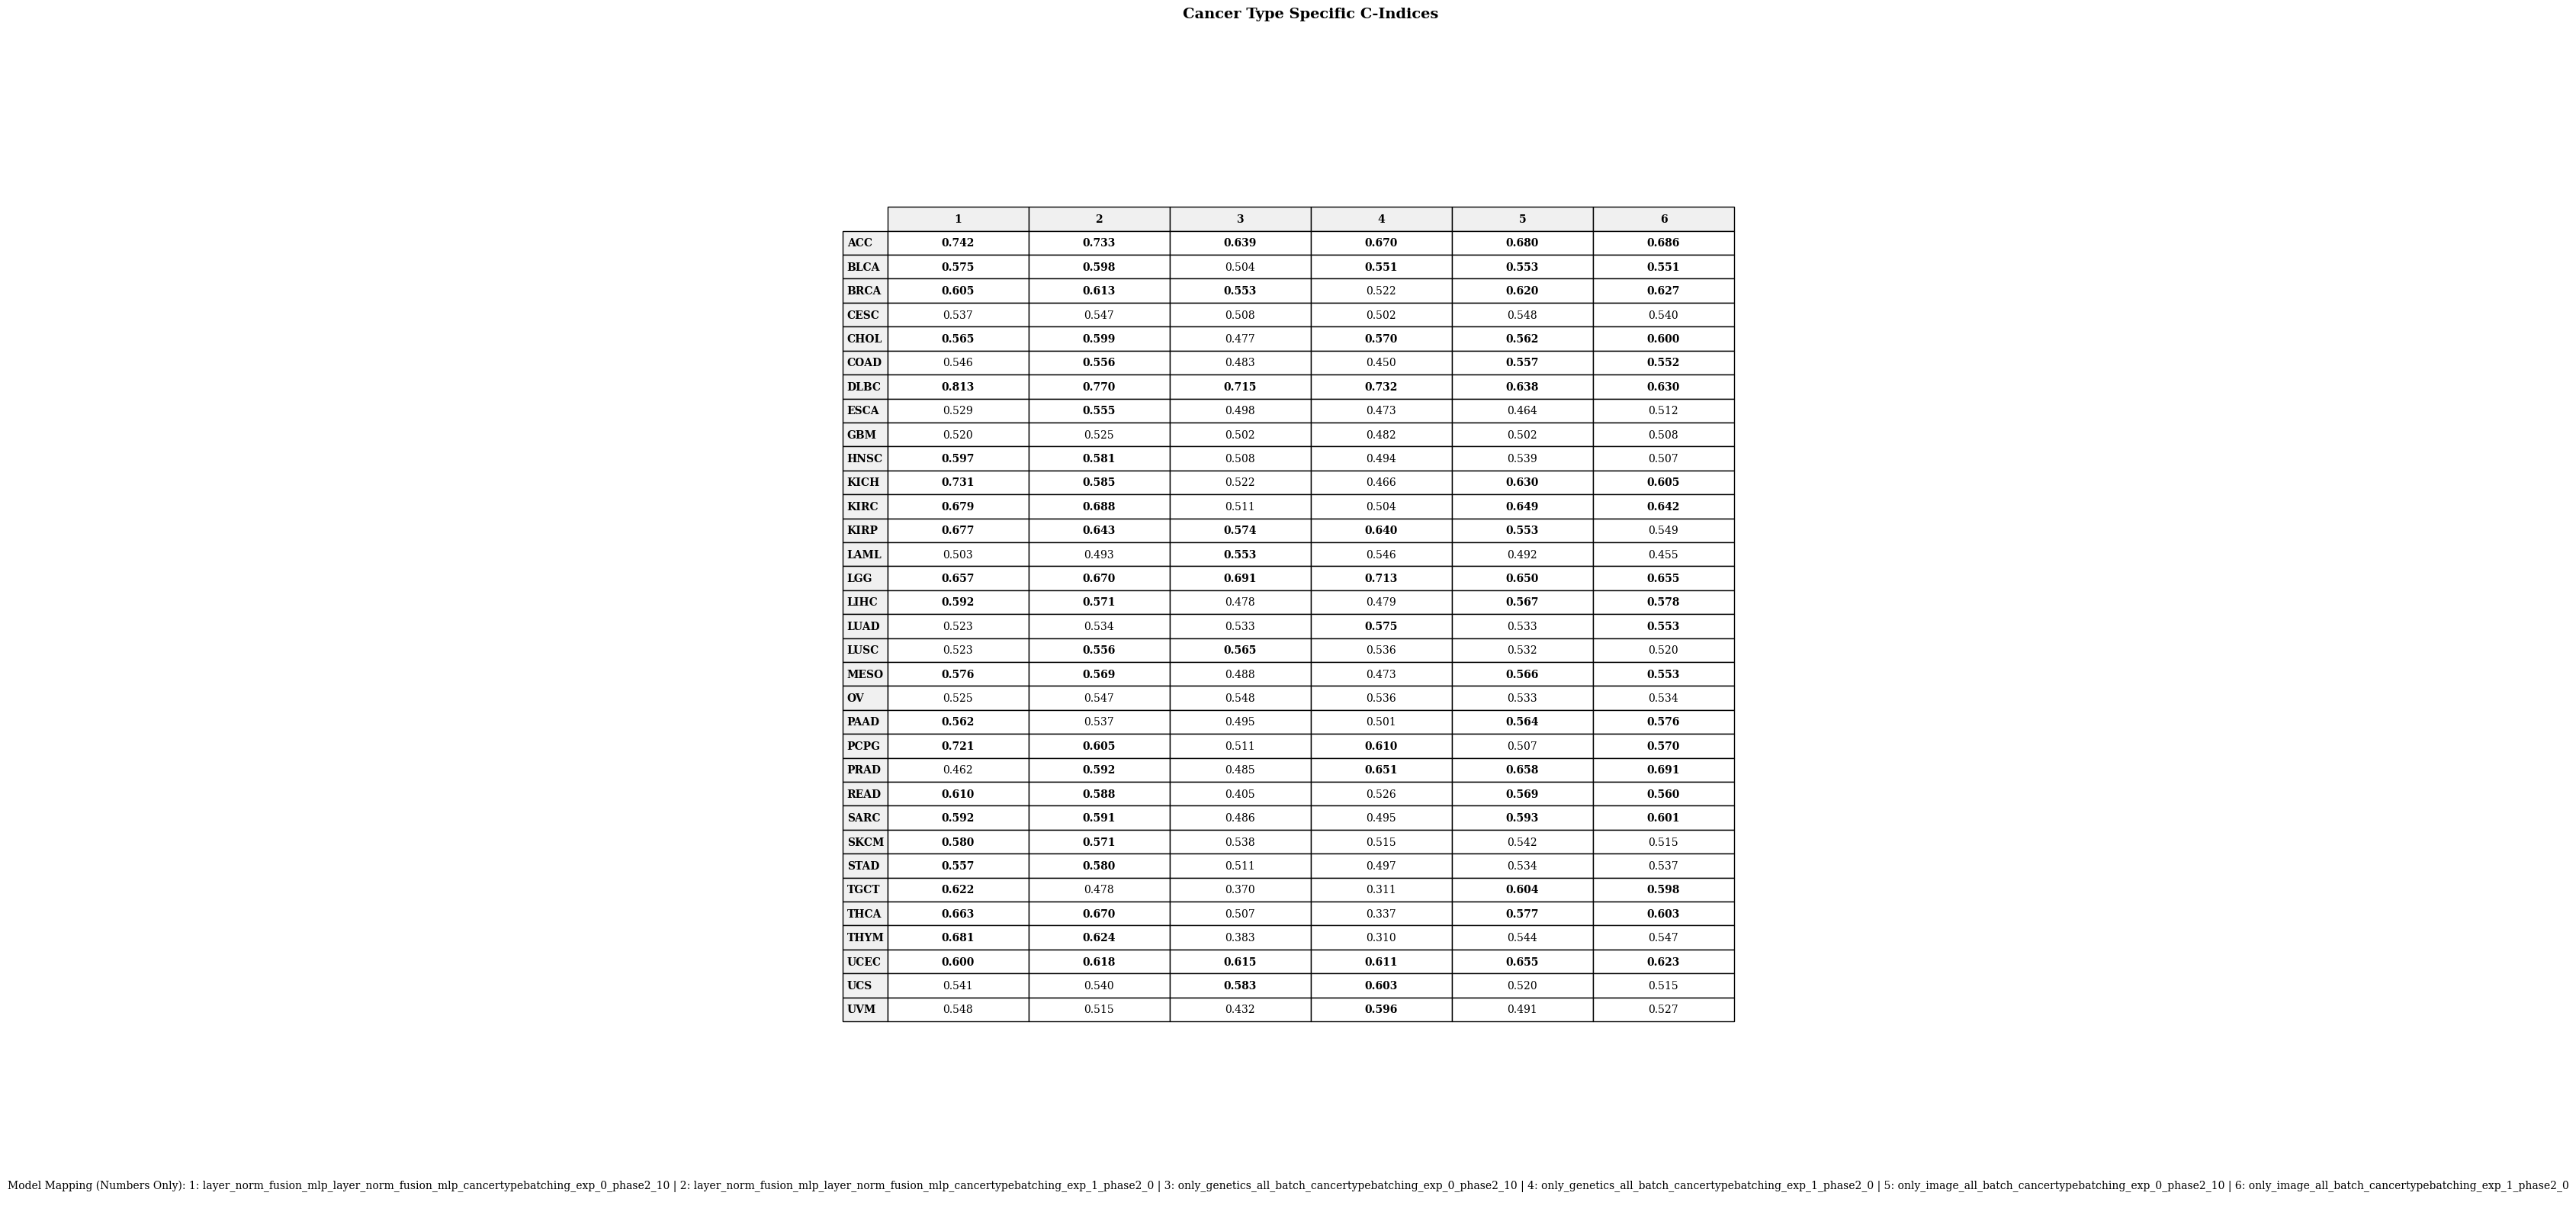

In [252]:
import matplotlib.pyplot as plt
import pandas.plotting as pd_plotting

# -- Set a scientific style --
plt.rcParams.update({'font.family': 'serif', 'font.size': 10})

# Create a mapping from full model names (i.e. the pivot table's column names)
# to sequential numbers.
model_mapping = {model: i+1 for i, model in enumerate(pivot_cindices.columns)}

# Create a new version of the pivot table with the model columns renamed to numbers.
pivot_numeric = pivot_cindices.rename(columns=model_mapping)
# Round values to three decimals.
pivot_numeric = pivot_numeric.round(3)

# Start the figure.
fig, ax = plt.subplots(figsize=(12, 16))
ax.axis('off')  # Remove axes for a clean table look

# Draw the table using pandas plotting.
tbl = pd_plotting.table(ax, pivot_numeric, loc='center', cellLoc='center', 
                          colWidths=[0.2] * len(pivot_numeric.columns))

# Iterate through the table cells to customize styling.
for (row, col), cell in tbl.get_celld().items():
    # Header row (column names) and index labels (if any) are styled in bold with a light background.
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold', size=12)
        cell.set_facecolor('#f0f0f0')
    else:
        try:
            # Data rows start at row 1 (since row 0 is headers), so subtract one.
            val = pivot_numeric.iloc[row - 1, col]
            # Bold the text if the value is above 0.550.
            if val > 0.550:
                cell.set_text_props(weight='bold')
            # Force the display to three decimals.
            cell.get_text().set_text(f"{val:.3f}")
        except IndexError:
            pass

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

# Add a title above the table.
plt.title("Cancer Type Specific C-Indices", fontsize=14, weight='bold')

# Build a mapping text string that shows each model number and its corresponding full name.
mapping_lines = [f"{num}: {model}" for model, num in model_mapping.items()]
mapping_text = "Model Mapping (Numbers Only): " + " | ".join(mapping_lines)

# Place the mapping text at the bottom of the figure.
fig.text(0.5, 0.02, mapping_text, ha='center', va='bottom', fontsize=10, family='serif')

plt.tight_layout()
plt.show()


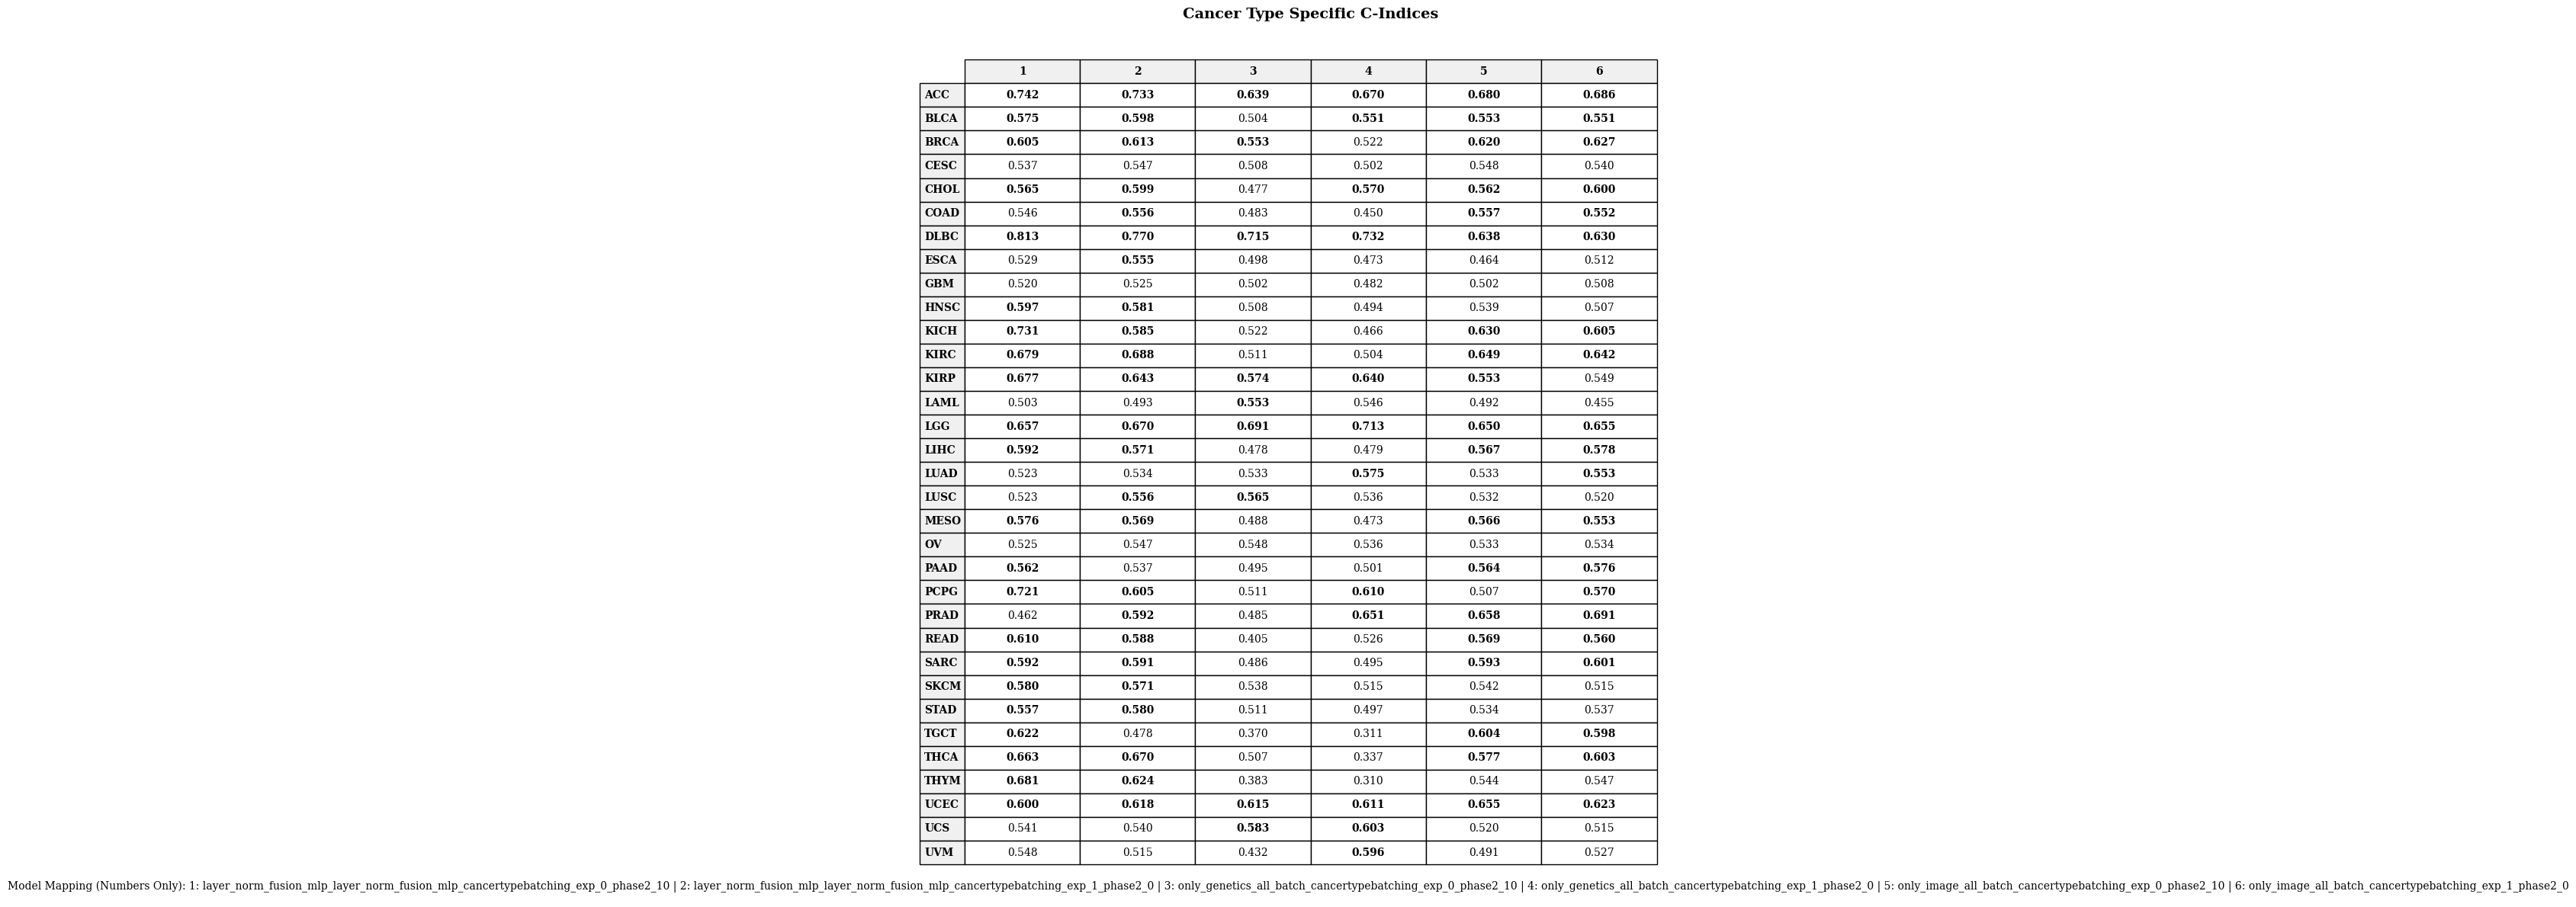

In [253]:
import matplotlib.pyplot as plt
import pandas.plotting as pd_plotting

# Convert cm to inches (1 inch = 2.54 cm)
width_cm = 7    # Approximate width in centimeters (or choose 6 if preferred)
height_cm = 10  # Height in centimeters
width_in = width_cm / 2.54
height_in = height_cm / 2.54

# -- Set a scientific style --
plt.rcParams.update({'font.family': 'serif', 'font.size': 10})

# Create a mapping from the full model names (column names) to sequential model numbers.
model_mapping = {model: i+1 for i, model in enumerate(pivot_cindices.columns)}

# Create a new version of the pivot table with model columns renamed to sequential numbers.
pivot_numeric = pivot_cindices.rename(columns=model_mapping)
# Round values to three decimals.
pivot_numeric = pivot_numeric.round(3)

# Set up the figure with the dimensions in inches.
fig, ax = plt.subplots(figsize=(10, 12))
ax.axis('off')  # Remove axes for a clean look

# Draw the table using pandas plotting.
tbl = pd_plotting.table(ax, pivot_numeric, loc='center', cellLoc='center', 
                          colWidths=[0.2] * len(pivot_numeric.columns))

# Style the table cells.
for (row, col), cell in tbl.get_celld().items():
    # Header row (row 0) and the index labels (col -1) are styled in bold with a light background.
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold', size=12)
        cell.set_facecolor('#f0f0f0')
    else:
        try:
            # Adjust for header row offset (data rows start at row 1)
            val = pivot_numeric.iloc[row - 1, col]
            # Bold text for values above 0.55.
            if val > 0.550:
                cell.set_text_props(weight='bold')
            # Format the value with three decimals.
            cell.get_text().set_text(f"{val:.3f}")
        except IndexError:
            pass

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

# Add a title above the table.
plt.title("Cancer Type Specific C-Indices", fontsize=14, weight='bold')

# Build a mapping string for model numbers to full model names.
mapping_lines = [f"{num}: {model}" for model, num in model_mapping.items()]
mapping_text = "Model Mapping (Numbers Only): " + " | ".join(mapping_lines)

# Place the mapping text at the bottom center.
fig.text(0.5, 0.02, mapping_text, ha='center', va='bottom', fontsize=10, family='serif')

# Tighten layout and save the figure without extra white space.
plt.tight_layout()

# Save the figure. Using bbox_inches='tight' and pad_inches=0 minimizes extra white space.
fig.savefig("scientific_table.png", bbox_inches='tight', pad_inches=0)

plt.show()
